In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [59]:
df=pd.read_csv("/content/drive/MyDrive/Ai/i1.csv")

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7242 entries, 0 to 7241
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         7242 non-null   object 
 1   Timestamp    7242 non-null   object 
 2   Invoice No.  7242 non-null   int64  
 3   Item Name    7242 non-null   object 
 4   Price        7242 non-null   float64
 5   Qty.         7242 non-null   float64
 6   Sub Total    7242 non-null   float64
 7   Discount     7242 non-null   float64
 8   Tax          7242 non-null   float64
 9   Final Total  7242 non-null   float64
 10  Table No.    7242 non-null   int64  
 11  Server Name  7242 non-null   object 
 12  Covers       7242 non-null   int64  
 13  Variation    8 non-null      object 
 14  Category     7242 non-null   object 
 15  HSN          0 non-null      float64
dtypes: float64(7), int64(3), object(6)
memory usage: 905.4+ KB


In [61]:
df.isna().sum()

,0
Date,0
Timestamp,0
Invoice No.,0
Item Name,0
Price,0
Qty.,0
Sub Total,0
Discount,0
Tax,0
Final Total,0


In [63]:
from sklearn.impute import SimpleImputer
imr=SimpleImputer(strategy='most_frequent')
df[['Variation']]=imr.fit_transform(df[['Variation']])

In [64]:
df.isna().sum()

,0
Date,0
Timestamp,0
Invoice No.,0
Item Name,0
Price,0
Qty.,0
Sub Total,0
Discount,0
Tax,0
Final Total,0


In [66]:
df=df.drop('HSN', axis=1)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7242 entries, 0 to 7241
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         7242 non-null   object 
 1   Timestamp    7242 non-null   object 
 2   Invoice No.  7242 non-null   int64  
 3   Item Name    7242 non-null   object 
 4   Price        7242 non-null   float64
 5   Qty.         7242 non-null   float64
 6   Sub Total    7242 non-null   float64
 7   Discount     7242 non-null   float64
 8   Tax          7242 non-null   float64
 9   Final Total  7242 non-null   float64
 10  Table No.    7242 non-null   int64  
 11  Server Name  7242 non-null   object 
 12  Covers       7242 non-null   int64  
 13  Variation    7242 non-null   object 
 14  Category     7242 non-null   object 
dtypes: float64(6), int64(3), object(6)
memory usage: 848.8+ KB


In [68]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
n=df.select_dtypes(include=['object'])
for col in n.columns:
  df[col]=le.fit_transform(df[col])

df

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category
0,79,2198,28389,128,55.0,1.0,55.0,0.0,2.76,57.76,16,0,0,1,1
1,79,2198,28389,173,30.0,4.0,120.0,0.0,6.00,126.00,16,0,0,1,1
2,79,2198,28389,156,150.0,1.0,150.0,0.0,7.50,157.50,16,0,0,1,12
3,79,2198,28389,166,150.0,1.0,150.0,0.0,7.50,157.50,16,0,0,1,12
4,79,2198,28389,92,120.0,1.0,120.0,0.0,6.00,126.00,16,0,0,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7237,0,3,26194,133,50.0,1.0,50.0,0.0,2.50,52.50,3,0,0,1,0
7238,0,3,26194,142,20.0,1.0,20.0,0.0,1.00,21.00,3,0,0,1,0
7239,0,2,26193,133,50.0,3.0,150.0,0.0,7.50,157.50,10,0,0,1,0
7240,0,1,26192,164,120.0,1.0,120.0,0.0,6.00,126.00,4,0,0,1,0


/tmp/ipykernel_3370/160573771.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(n.values,labels=n.columns)


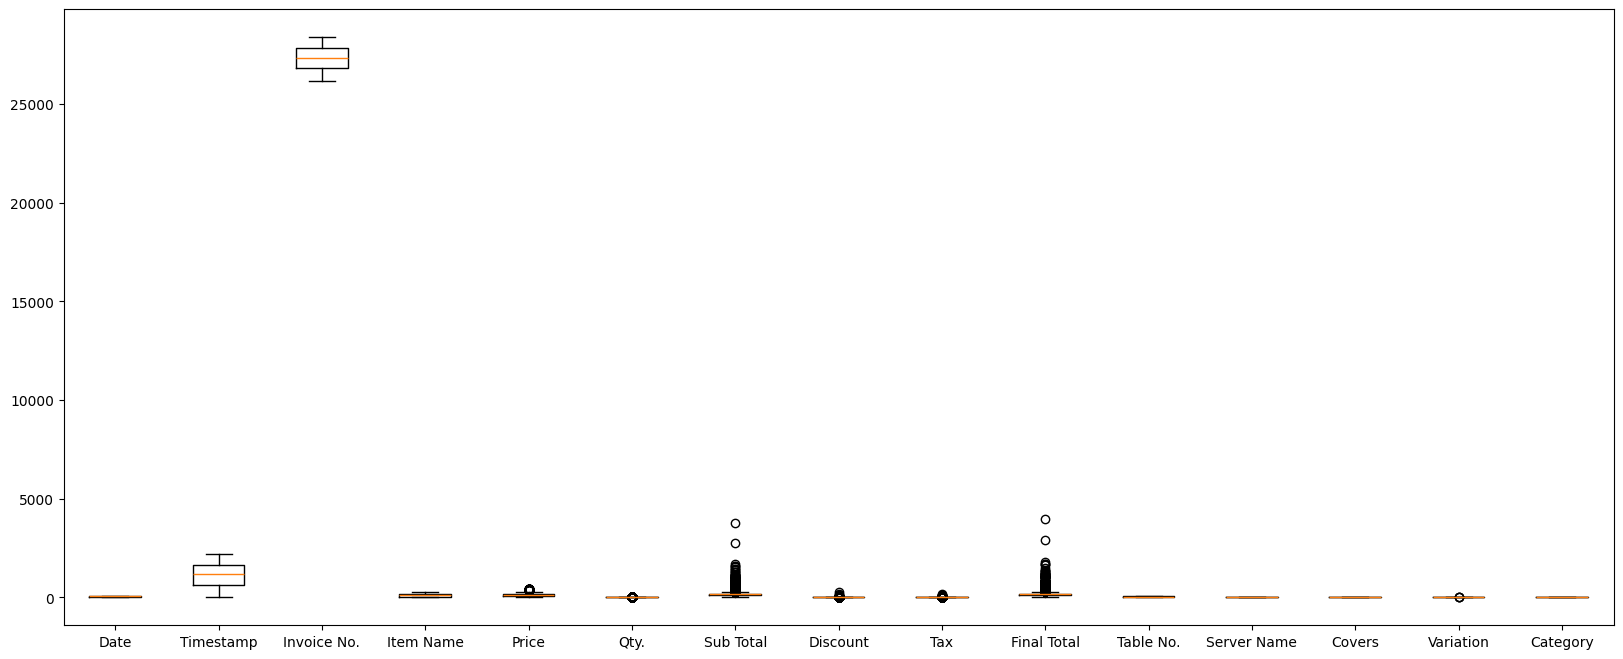

In [69]:
n=df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(20,8))
plt.boxplot(n.values,labels=n.columns)
plt.show()

In [70]:
n=df.select_dtypes(include=['float64','int64']).columns
for col in n:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  df[col]=df[col].clip(lower,upper)
df

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category
0,79,2198,28389,128,55.0,1.0,55.0,0.0,2.76,57.76,16,0,0,1,1
1,79,2198,28389,173,30.0,1.0,120.0,0.0,6.00,126.00,16,0,0,1,1
2,79,2198,28389,156,150.0,1.0,150.0,0.0,7.50,157.50,16,0,0,1,12
3,79,2198,28389,166,150.0,1.0,150.0,0.0,7.50,157.50,16,0,0,1,12
4,79,2198,28389,92,120.0,1.0,120.0,0.0,6.00,126.00,16,0,0,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7237,0,3,26194,133,50.0,1.0,50.0,0.0,2.50,52.50,3,0,0,1,0
7238,0,3,26194,142,20.0,1.0,20.0,0.0,1.00,21.00,3,0,0,1,0
7239,0,2,26193,133,50.0,1.0,150.0,0.0,7.50,157.50,10,0,0,1,0
7240,0,1,26192,164,120.0,1.0,120.0,0.0,6.00,126.00,4,0,0,1,0


/tmp/ipykernel_3370/160573771.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(n.values,labels=n.columns)


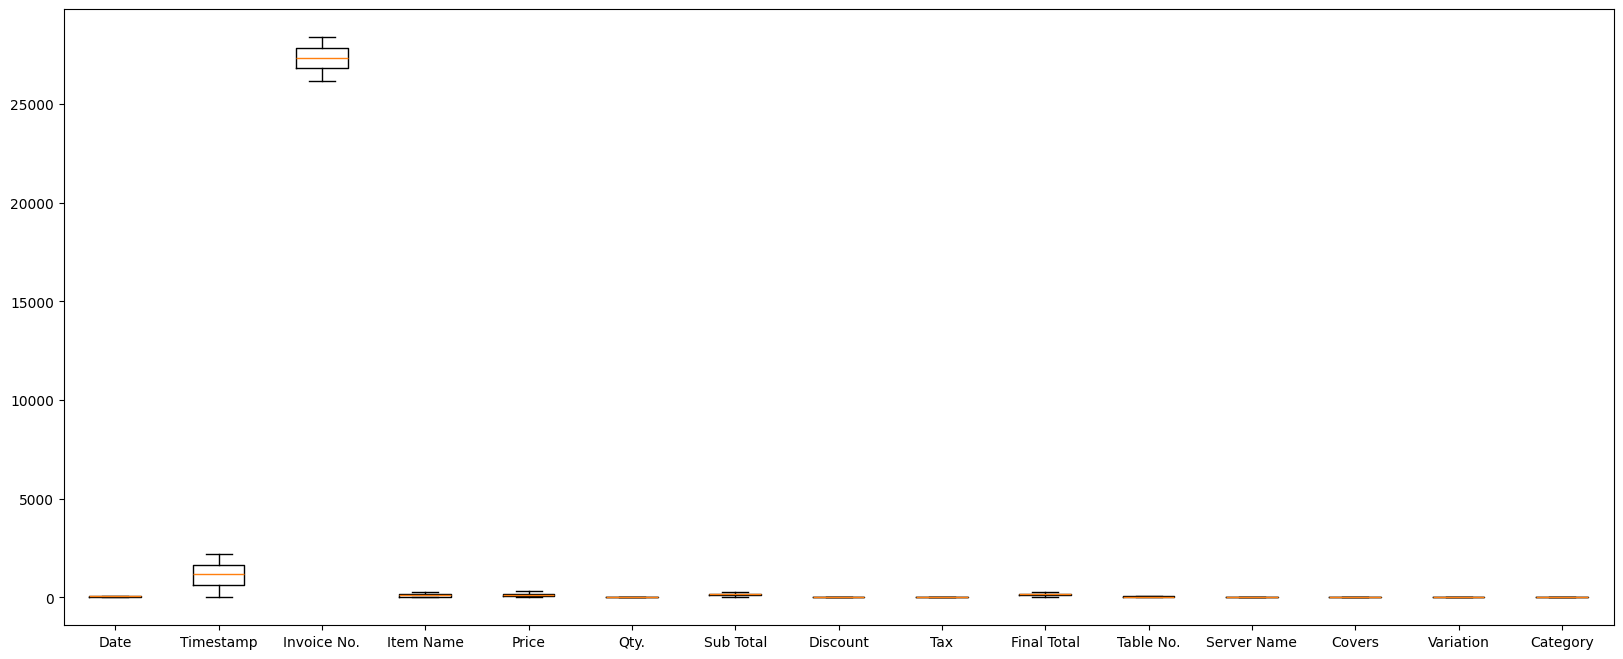

In [71]:
n=df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(20,8))
plt.boxplot(n.values,labels=n.columns)
plt.show()

In [73]:
X = df.drop('Category', axis=1)
y = df['Category']

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=45)

Accuracy Score: 0.6488128106018775


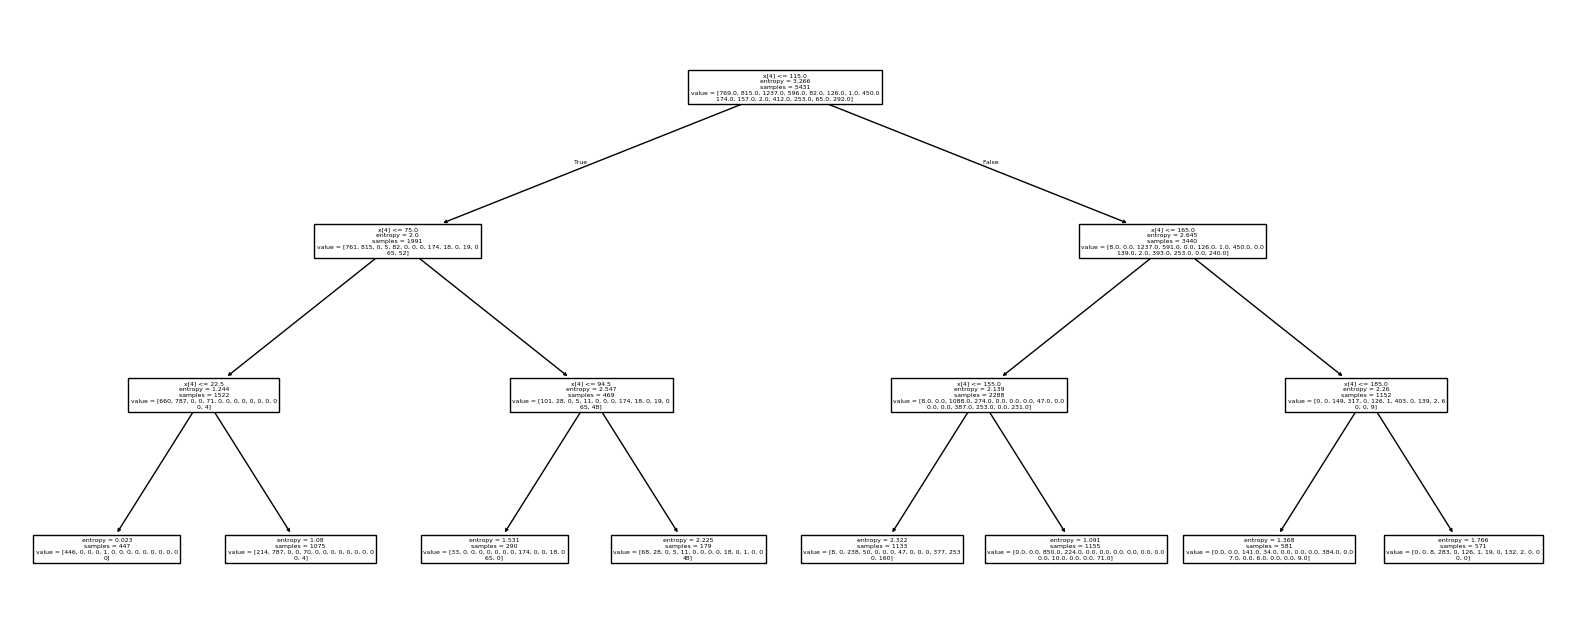

In [76]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(criterion="entropy",max_depth=3)
clf = clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:", accuracy_score(y_test, y_pred))

from matplotlib import pyplot as plt
from sklearn import tree
fig=plt.figure(figsize=(20,8))
tree.plot_tree(clf)
plt.show()

In [77]:
#Random Forest

X = df.drop('Category', axis=1)
y = df['Category']

from sklearn.ensemble import RandomForestClassifier
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9316770186335404


In [78]:
X = df[['Price', 'Qty.', 'Tax', 'Discount']]
y = df['Category']

from sklearn.ensemble import RandomForestClassifier
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.svm import SVC
model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.6211180124223602


In [79]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy Score:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy Score: 0.7625948930296756


In [80]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy Score:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy Score: 0.7287784679089027


Mean Squared Error: 16.4896
Mean Absolute Error: 3.3948
R2 Score: 0.1226


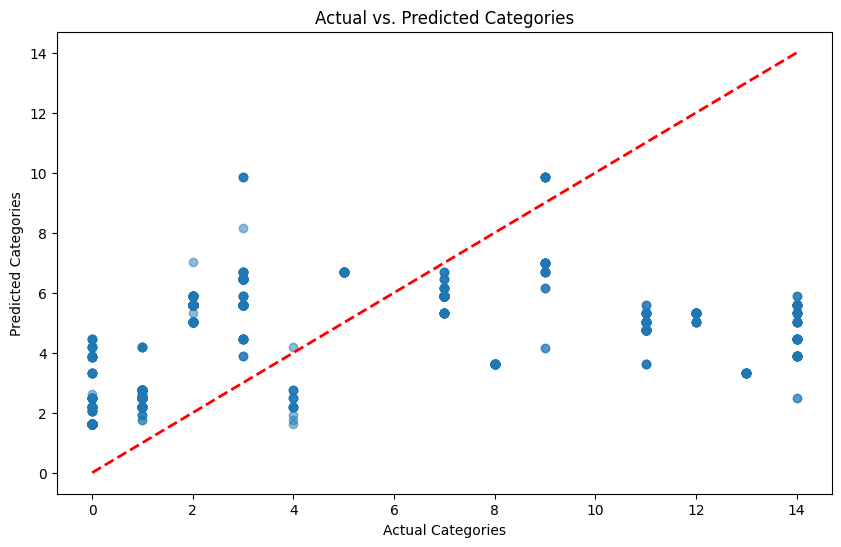

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


X= df[['Price']]
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=45)

li = LinearRegression()
li.fit(X_train, y_train)

y_pred = li.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")


plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Regression line
plt.xlabel("Actual Categories")
plt.ylabel("Predicted Categories")
plt.title("Actual vs. Predicted Categories")

plt.show()